In [5]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df= pd.read_csv("Airbnb_Open_Data.csv")

In [7]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [8]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

# Chech for Missing Values

In [9]:
print(df.isnull().sum())

id                                   0
NAME                                56
host id                              0
host_identity_verified              73
host name                           19
neighbourhood group                 27
neighbourhood                       16
lat                                  8
long                                 8
country                             50
country code                        80
instant_bookable                    80
cancellation_policy                 51
room type                            1
Construction year                  136
price                               12
service fee                         16
minimum nights                      85
number of reviews                    7
last review                        164
reviews per month                  150
review rate number                  94
calculated host listings count      16
availability 365                   149
house_rules                        885
license                  

# Handling Missing Values

In [10]:
df['last review']=pd.to_datetime(df['last review'],errors='coerce')

In [11]:
df.info

<bound method DataFrame.info of            id                                               NAME      host id  \
0     1001254                 Clean & quiet apt home by the park  80014485718   
1     1002102                              Skylit Midtown Castle  52335172823   
2     1002403                THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3     1002755                                                NaN  85098326012   
4     1003689   Entire Apt: Spacious Studio/Loft by central park  92037596077   
...       ...                                                ...          ...   
2690  2487023                           Artsy Harlem Guest Space  18322668208   
2691  2487575                                Saratoga Park Suite  87625848473   
2692  2488128                  Spacious Duplex in Fun & Hip Area  47642466674   
2693  2488680  Large Room In Newly Renovated Hell's Kitchen Apt.  55835327316   
2694  2489232  New Law in New York | NO  rentals under 30 days..  47374842569

In [12]:
df.fillna({'reviews per month': 0, 'last review': df['last review'].min()}, inplace=True)

In [13]:
df.dropna (subset=['NAME', 'host name'], inplace=True)

In [14]:
print(df.isnull().sum())

id                                   0
NAME                                 0
host id                              0
host_identity_verified              63
host name                            0
neighbourhood group                 24
neighbourhood                       16
lat                                  8
long                                 8
country                             44
country code                        71
instant_bookable                    71
cancellation_policy                 45
room type                            1
Construction year                  123
price                               12
service fee                         16
minimum nights                      79
number of reviews                    6
last review                          0
reviews per month                    0
review rate number                  82
calculated host listings count      15
availability 365                   121
house_rules                        869
license                  

# Correct Data Types

In [15]:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float) 
df['service fee'] = df['service fee'].replace(r'[\$,]', '', regex=True).astype(float)

In [16]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,2012-07-11,0.00,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,115.0,3.0,74.0,2019-06-22,0.59,3.0,1.0,374.0,"No smoking, please, and no drugs.",NaN


# Descriptive Statistics

In [17]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,license
count,2.626000e+03,2.626000e+03,2618.000000,2618.000000,2503.00000,2614.000000,2610.000000,2547.000000,2620.000000,2626,2626.000000,2544.000000,2611.000000,2505.000000,0.0
mean,1.761422e+06,4.885554e+10,40.727850,-73.962239,2012.39992,615.904744,122.938314,12.918335,67.453435,2018-03-27 19:41:43.274942720,0.858252,3.001965,2.160858,206.707784,NaN
min,1.001254e+06,1.316021e+08,40.508680,-74.239860,2003.00000,50.000000,10.000000,-12.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000,NaN
25%,1.401892e+06,2.431426e+10,40.687530,-73.984628,2007.00000,338.000000,67.000000,2.000000,10.000000,2017-08-20 06:00:00,0.140000,2.000000,1.000000,96.000000,NaN
50%,1.764338e+06,4.837361e+10,40.721850,-73.961535,2012.00000,615.500000,123.000000,3.000000,34.000000,2019-05-04 00:00:00,0.470000,3.000000,1.000000,206.000000,NaN
75%,2.126785e+06,7.346478e+10,40.760008,-73.946355,2017.00000,900.750000,179.750000,7.000000,95.000000,2019-06-22 00:00:00,1.210000,4.000000,2.000000,316.000000,NaN
max,2.489232e+06,9.872629e+10,40.897470,-73.733230,2022.00000,1200.000000,240.000000,3455.000000,607.000000,2058-06-16 00:00:00,10.000000,5.000000,52.000000,426.000000,NaN
std,4.233737e+05,2.842065e+10,0.052135,0.035739,5.81986,331.074702,66.161518,76.932125,83.264905,NaN,1.055122,1.420732,4.673248,125.135888,NaN


# Remove Duplicates

In [18]:
df.drop_duplicates (inplace=True)

# Confirm Data Cleaning

In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2626 entries, 0 to 2694
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              2626 non-null   int64         
 1   NAME                            2626 non-null   object        
 2   host id                         2626 non-null   int64         
 3   host_identity_verified          2563 non-null   object        
 4   host name                       2626 non-null   object        
 5   neighbourhood group             2602 non-null   object        
 6   neighbourhood                   2610 non-null   object        
 7   lat                             2618 non-null   float64       
 8   long                            2618 non-null   float64       
 9   country                         2582 non-null   object        
 10  country code                    2555 non-null   object        
 11  instant_b

# Visualization

# Distribution of Prices

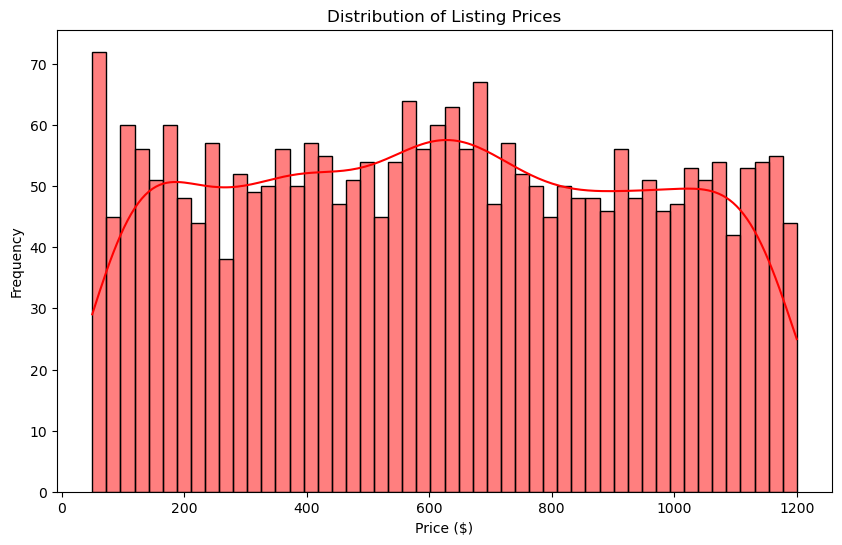

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'],bins=50,kde=True,color='red')
plt.title('Distribution of Listing Prices')

plt.xlabel('Price ($)')

plt.ylabel('Frequency')

plt.show()

# Room type Analysis

In [21]:
df['room type']

0          Private room
1       Entire home/apt
2          Private room
4       Entire home/apt
5       Entire home/apt
             ...       
2690    Entire home/apt
2691       Private room
2692    Entire home/apt
2693       Private room
2694                NaN
Name: room type, Length: 2626, dtype: object

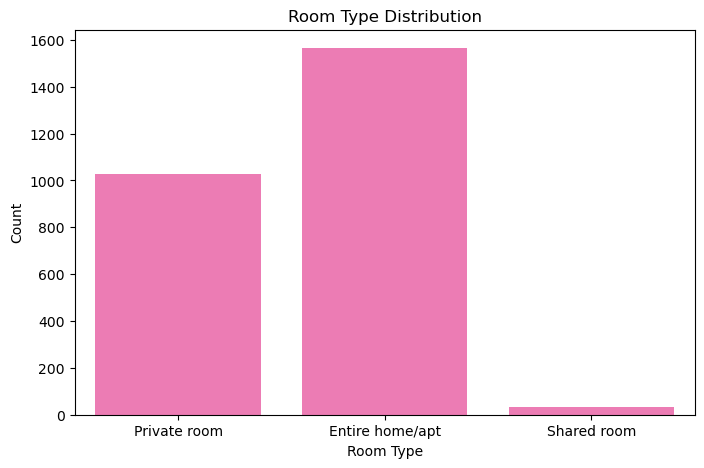

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(x='room type', data=df, color='hotpink')

plt.title('Room Type Distribution')

plt.xlabel('Room Type')

plt.ylabel('Count')

plt.show()

# Neighborhood Analysis

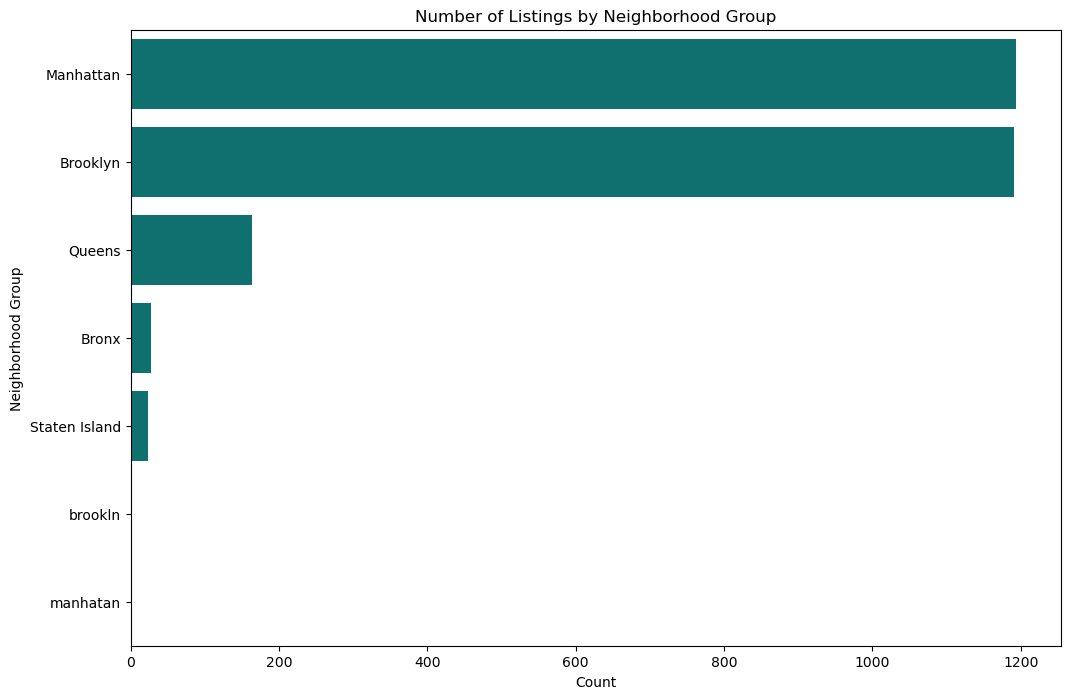

In [23]:
plt.figure(figsize=(12, 8))

sns.countplot(y='neighbourhood group', data=df, color="teal", order= df['neighbourhood group'].value_counts().index)

plt.title('Number of Listings by Neighborhood Group')

plt.xlabel('Count')

plt.ylabel('Neighborhood Group')

plt.show()

# Price vs. Room Type

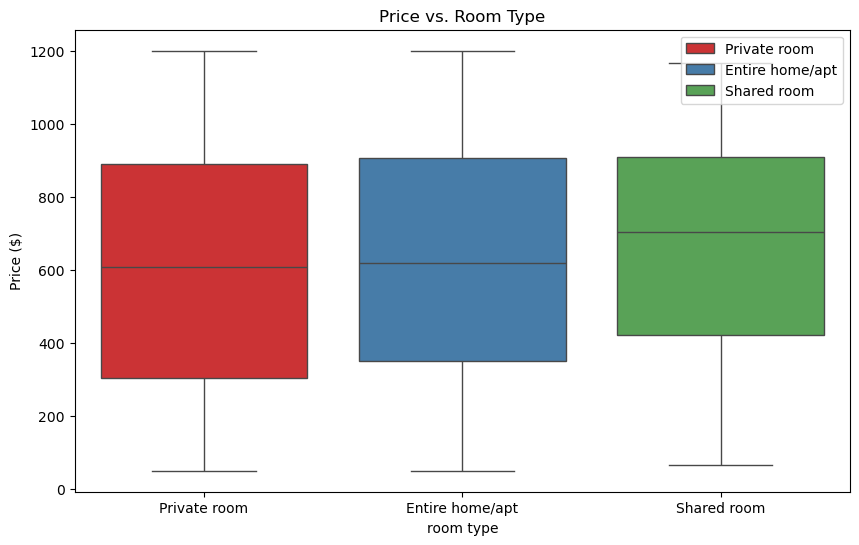

In [27]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='room type', y='price', hue='room type', data = df, palette='Set1')

plt.title('Price vs. Room Type')

plt.xlabel('room type')

plt.ylabel('Price ($)')

plt.legend(title='room type')
plt.legend(loc='upper right')
plt.show()

# Reviews Over Time

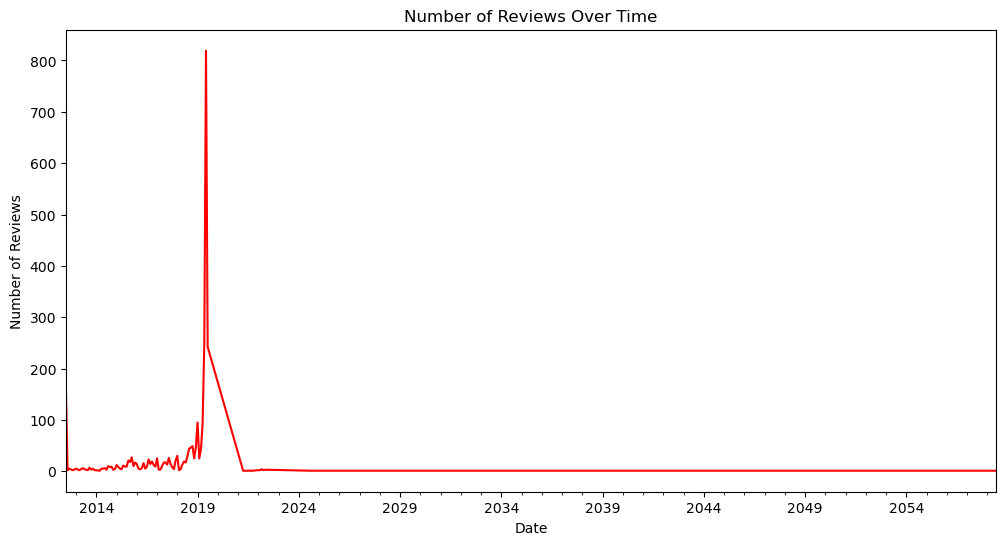

In [28]:
df['last review'] = pd.to_datetime(df ['last review'])

reviews_over_time = df.groupby(df['last review'].dt.to_period('M')).size()

plt.figure(figsize=(12, 6))

reviews_over_time.plot(kind='line', color='red')

plt.title('Number of Reviews Over Time')

plt.xlabel('Date')

plt.ylabel('Number of Reviews')

plt.show()